In [1]:
from src.acquisition import *

from pathlib import Path
root = Path.cwd()

import pandas as pd

from osgeo import gdal
gdal.SetConfigOption("GDAL_HTTP_UNSAFESSL", "YES")
gdal.SetConfigOption('GDAL_HTTP_COOKIEFILE','~/cookies.txt')
gdal.SetConfigOption('GDAL_HTTP_COOKIEJAR', '~/cookies.txt')
gdal.SetConfigOption('GDAL_DISABLE_READDIR_ON_OPEN','YES')
gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','TIF')

In [2]:
b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')

b

,boro_code,boro_name,shape_area,shape_leng,geometry
0,2.0,Bronx,1.186612e+09,462958.187578,"MULTIPOLYGON (((593066.658 4516675.698, 593055..."
1,5.0,Staten Island,1.623757e+09,325956.009000,"MULTIPOLYGON (((580375.284 4491060.737, 580378..."
2,3.0,Brooklyn,1.937593e+09,738745.842115,"MULTIPOLYGON (((595882.111 4492983.277, 595829..."
3,4.0,Queens,3.045878e+09,904188.424488,"MULTIPOLYGON (((598434.302 4494444.181, 598425..."
4,1.0,Manhattan,6.366027e+08,361212.476098,"MULTIPOLYGON (((583578.458 4504203.877, 583494..."


### Query API

In [4]:
TC_FILENAME = 'tc_new_york_10m.tif'
CITY = 'nyc'
borough = 'bronx'
BOUNDARY_FILE = 'nyc_boundary.gpkg'


landsat_catalog = "HLSL30.v2.0"
landsat_bands = ["B02","B03","B04","B05","B06","B07","B10","B11","Fmask"]
sentinel_catalog = "HLSS30.v2.0"
sentinel_bands = ["B02","B03","B04","B05","B06","B07","B8A","B11","B12","Fmask"]

# read in city vector data
boundary, bbox_utm, bbox_4326, shoreline = read_vector(boundary_file=BOUNDARY_FILE,root=root,cheasapeake=False)

# bronx, manhattan
boundary = boundary.loc[[0],:]
# brooklyn, staten island
#boundary = boundary.loc[[1,2],:]

boundary_4326 = boundary.to_crs(epsg=4326)
bbox_utm = tuple(boundary.total_bounds)
bbox_4326 = tuple(boundary_4326.total_bounds)


# query API, crop satellite data to boundaries
FROM_DATE = '2019-04-01'
TO_DATE = '2019-11-30'
sentinel_crop = get_stac_items(catalog_name=sentinel_catalog,
                   from_date=FROM_DATE, 
                   to_date=TO_DATE,
                   bbox_utm=bbox_utm,
                   bbox_4326=bbox_4326,
                   boundary=boundary,
                   bands=sentinel_bands,
                   shoreline=shoreline)

# FROM_DATE = '2019-07-01'
# TO_DATE = '2019-11-30'
# landsat_crop = get_stac_items(catalog_name=landsat_catalog,
#                    from_date=FROM_DATE, 
#                    to_date=TO_DATE,
#                    bbox_utm=bbox_utm,
#                    bbox_4326=bbox_4326,
#                    boundary=boundary,
#                    bands=landsat_bands,
#                    shoreline=shoreline)



### Landsat

In [ ]:
l_drop_2019 = check_data(landsat_crop,'first')
#l_drop_2016.isel(band=3).plot(col='time',col_wrap=3)

In [5]:
# drop manually when there aren't that many
to_drop = l_drop_2017.time.values[[1,3,5,7,9,11,12,13,14,16,17,18,19,20,22,23,24]]
l_drop_2017_filtered = l_drop_2017.drop_sel({'time':to_drop})

In [12]:
l_nov = l_drop_2019.isel(time=12)
l_nov = l_nov.expand_dims({'time':[l_nov.coords['time'].values]})

l_jul = l_drop_2019.isel(time=0)
l_jul = l_jul.expand_dims({'time':[l_jul.coords['time'].values]})

### Sentinel

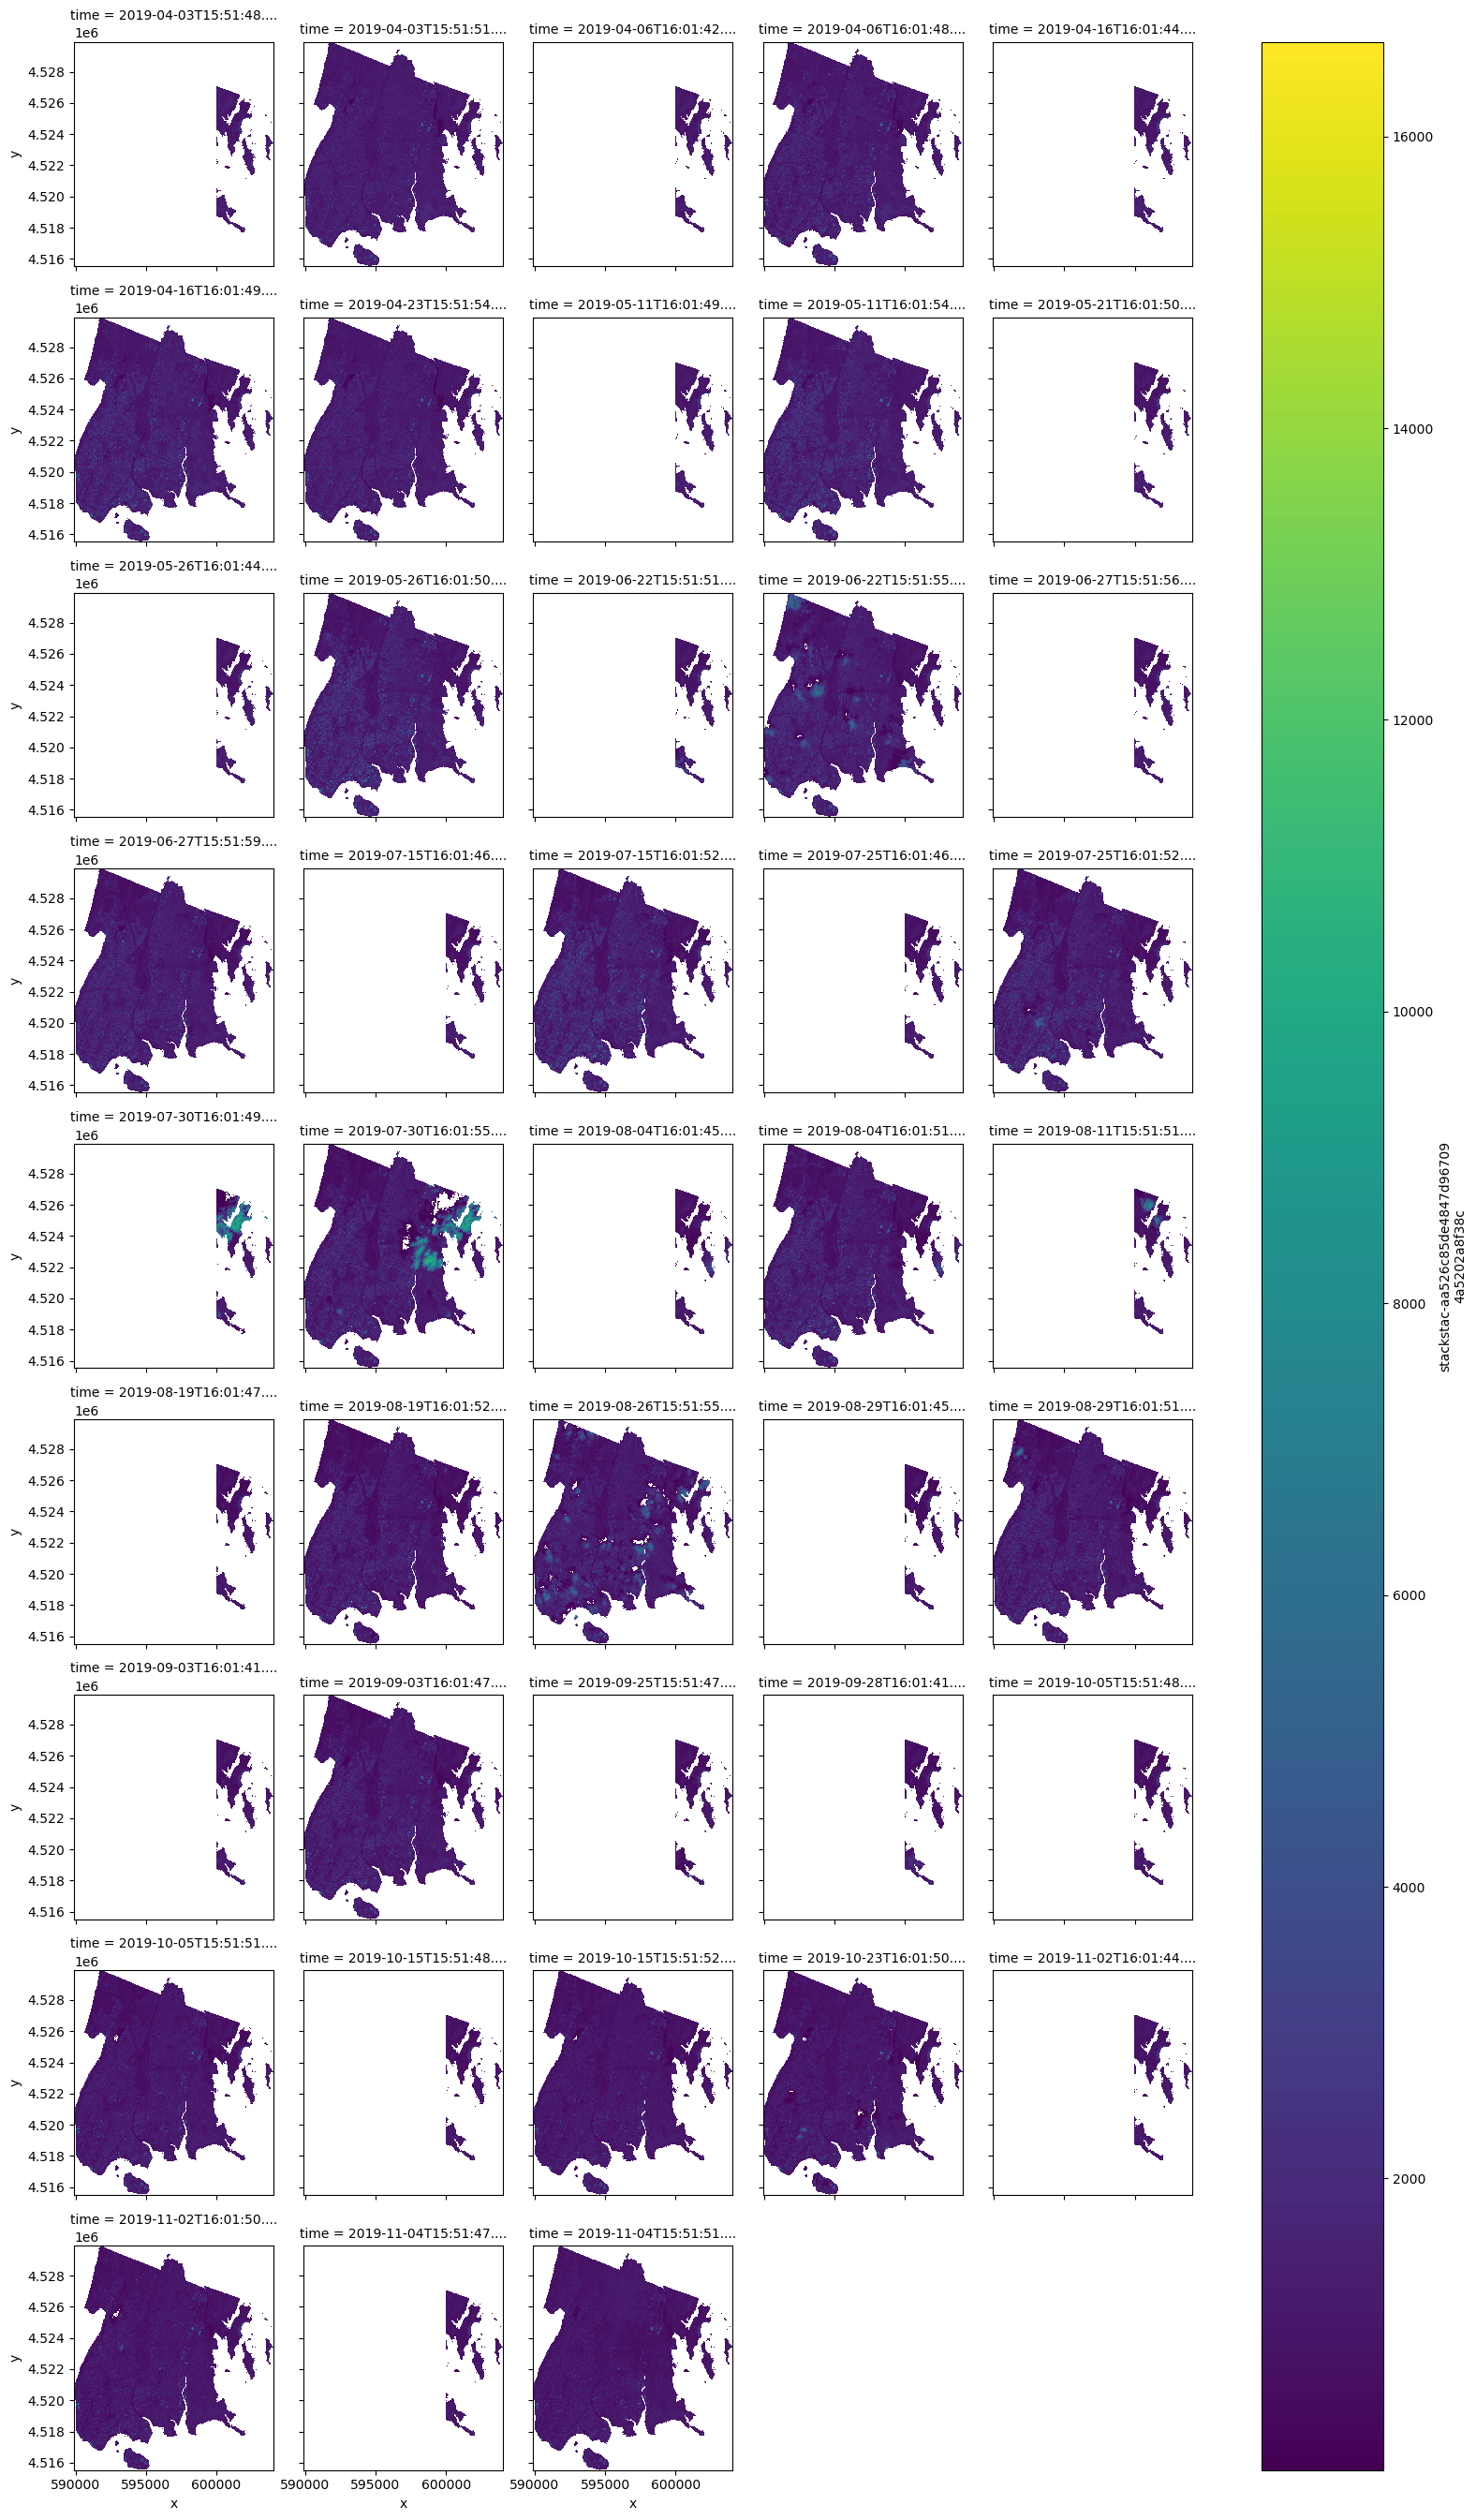

In [5]:
s_drop_2019 = check_data(sentinel_crop,'first')

In [22]:
s_sept = s_drop_2017.isel(time=[1,3])

In [19]:
s_may = s_drop_2018.isel(time=1)
s_may = s_may.expand_dims({'time':[s_may.coords['time'].values]})

s_jul = s_drop_2018.isel(time=8)
s_jul = s_jul.expand_dims({'time':[s_jul.coords['time'].values]})

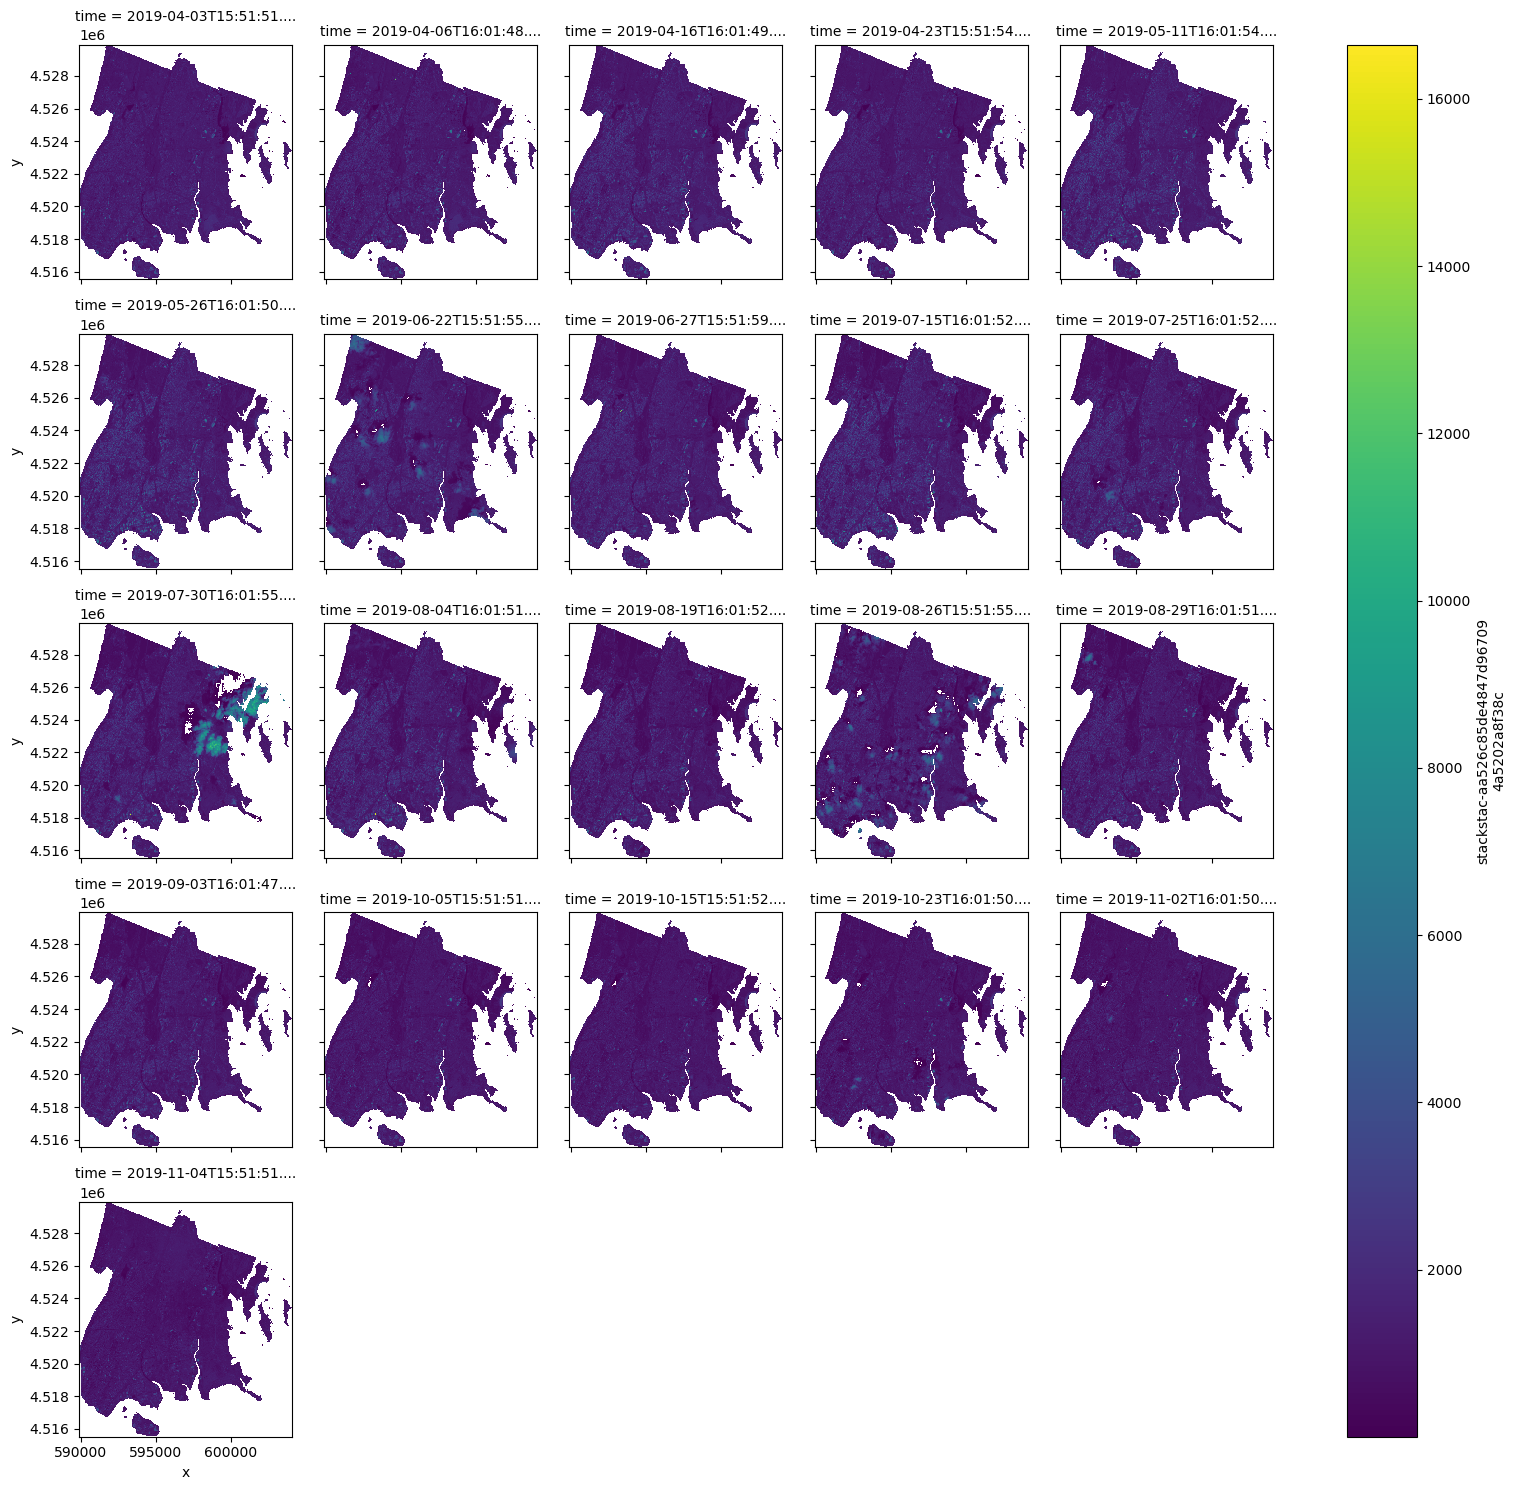

In [6]:
def filter_missing_data(data,time_with_missing_data):
    # get number of nas in time with missing data
    threshold = data.isel(band=3,time=time_with_missing_data).isnull().values.sum()
    # get number of nas in each time step
    nan_count = data.isnull().sum(dim=["x", "y"])

    # make boolean arrays showing if timesteps have na count less than threshold
    valid_slices = nan_count.values < threshold

    # get indices of valid timesteps
    keep_index = []
    for i,a in enumerate(valid_slices):
        if a[0] == True:
            keep_index.append(i)

            # filter the DataArray
    filtered = data.isel(time=keep_index)

    return filtered


s_drop_2019_filtered = filter_missing_data(s_drop_2019,time_with_missing_data=0)
s_drop_2019_filtered.isel(band=3).plot(col='time',col_wrap=5)

In [23]:
# save image dates to csv

all_landsat_times = np.concat([l_drop_2017_filtered.time.values, l_nov.time.values,l_jul.time.values])
all_sentinel_times = np.concat([s_drop_2019_filtered.time.values,s_may.time.values,s_jul.time.values,s_sept.time.values])

sdf = pd.DataFrame({'sentinel':all_sentinel_times})
ldf = pd.DataFrame({'landsat':all_landsat_times})       

new = pd.concat([sdf, ldf], axis=1) 
new.to_csv(root / 'output' / CITY / f'{borough}_satellite_images.csv')

In [24]:
# change landsat dates to same year and combine

# april and may from 2017
#l_april['time'] = l_april.time.to_index() - pd.Timedelta(days=365)
l_nov['time'] = l_nov.time.to_index() - pd.Timedelta(days=365*2)
l_jul['time'] = l_jul.time.to_index() - pd.Timedelta(days=365*2)


In [25]:
l_combine = l_drop_2017_filtered.combine_first(l_nov).combine_first(l_jul)

In [27]:
# change sentinel to same year as landsat for concatenation
s_drop_2019_filtered['time'] = s_drop_2019_filtered.time.to_index() - pd.Timedelta(days=365*2)

s_may['time'] = s_may.time.to_index() - pd.Timedelta(days=365)
s_jul['time'] = s_jul.time.to_index() - pd.Timedelta(days=365)

In [28]:
s_combine = s_drop_2019_filtered.combine_first(s_may).combine_first(s_jul).combine_first(s_sept)

c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


### Cloud Mask and Scale

In [29]:
l_masked = mask_and_scale2(l_combine, sensor='landsat',scale_factor1= .0001, scale_factor2= .01)
s_masked = mask_and_scale2(s_combine,sensor='sentinel',scale_factor1= .0001, scale_factor2=None)

### Calculate vegetation indices, merge landsat and sentinel data

In [30]:
all_unique_indices, all_annual_unique_indices = get_unique_indices(l_data=l_masked,s_data=s_masked)
all_shared_indices, all_annual_shared_indices = get_shared_indices(l_data=l_masked,s_data=s_masked)

t = concatenate_and_save_data(annual1=all_annual_unique_indices,annual2=all_annual_shared_indices,
                              monthly1=all_unique_indices,monthly2=all_shared_indices,root=root,
                              filename=f'{CITY}_{borough}_hls_indices')

c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 11
  result = blockwise(
c:\Users\roseh\miniconda3\envs\rs-env\Lib\site-packages\dask\array\core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 11
  result = blockwise(


In [31]:
all_unique_bands, all_annual_unique = get_unique_bands(l_data=l_masked,s_data=s_masked)
all_shared_bands, all_annual_shared = get_shared_bands(landsat_data=l_masked,sentinel_data=s_masked)


s = concatenate_and_save_data(annual1=all_annual_shared,annual2=all_annual_unique,
                              monthly1=all_unique_bands,monthly2=all_shared_bands, root=root,
                              filename=f'{CITY}_{borough}_hls_bands',
                              # extra arguments needed for adding tree canopy layer
                              add_canopy=True,shoreline=shoreline,tc_filename=TC_FILENAME,city_boundary=boundary)


### Save as Rasters

In [ ]:
# def save_monthly_rasters(data,filename):
#     months = ['april','may','june','july','august','september','october','november']
#     for i in range(0,8):
#         data.isel(time=i).rio.to_raster(root / 'data' / f'{filename}_{months[i]}.tif')


# all_annual.isel(time=0).rio.to_raster(root / 'data' / 'annual_bands.tif')     

# save_monthly_rasters(all_shared_bands,filename='shared_bands')
# save_monthly_rasters(all_unique_bands,filename='unique_bands')
# save_monthly_rasters(all_shared_indices,filename='shared_indices')